In [1]:
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print("Fake dataset:", fake_df.shape)
print("True dataset:", true_df.shape)

print("\nFake columns:")
print(fake_df.columns.tolist())

print("\nTrue columns:")
print(true_df.columns.tolist())

Fake dataset: (23481, 4)
True dataset: (21417, 4)

Fake columns:
['title', 'text', 'subject', 'date']

True columns:
['title', 'text', 'subject', 'date']


In [3]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print("Fake dataset:", fake_df.shape)
print("True dataset:", true_df.shape)

print("\nFake columns:")
print(fake_df.columns.tolist())

print("\nTrue columns:")
print(true_df.columns.tolist())

Fake dataset: (23481, 4)
True dataset: (21417, 4)

Fake columns:
['title', 'text', 'subject', 'date']

True columns:
['title', 'text', 'subject', 'date']


In [4]:
fake_df["label"] = 0
true_df["label"] = 1

print("0 = Fake News")
print("1 = True News")

0 = Fake News
1 = True News


In [6]:
df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

# Shuffle
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (44898, 5)


In [7]:
df = pd.concat(
    [fake_df, true_df],
    ignore_index=True
)

# Shuffle
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (44898, 5)


In [8]:
print(df.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [10]:
df["combined_text"] = (
    df["title"].astype(str) + " " +
    df["text"].astype(str)
)

In [11]:
df

,title,text,subject,date,label,combined_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,Donald Trump heads for Scotland to reopen a go...
...,...,...,...,...,...,...
44893,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...,,politics,"Mar 27, 2017",0,UNREAL! CBS’S TED KOPPEL Tells Sean Hannity He...
44894,PM May seeks to ease Japan's Brexit fears duri...,LONDON/TOKYO (Reuters) - British Prime Ministe...,worldnews,"August 29, 2017",1,PM May seeks to ease Japan's Brexit fears duri...
44895,Merkel: Difficult German coalition talks can r...,BERLIN (Reuters) - Chancellor Angela Merkel sa...,worldnews,"November 16, 2017",1,Merkel: Difficult German coalition talks can r...
44896,Trump Stole An Idea From North Korean Propaga...,Jesus f*cking Christ our President* is a moron...,News,"July 14, 2017",0,Trump Stole An Idea From North Korean Propaga...


In [13]:
df = df.drop(
    columns=["title", "text", "subject", "date"],
    errors="ignore"
)

df = df.rename(
    columns={"combined_text": "text"}
)

print(df.head())

   label                                               text
0      0  Ben Stein Calls Out 9th Circuit Court: Committ...
1      1  Trump drops Steve Bannon from National Securit...
2      1  Puerto Rico expects U.S. to lift Jones Act shi...
3      0   OOPS: Trump Just Accidentally Confirmed He Le...
4      1  Donald Trump heads for Scotland to reopen a go...


In [14]:
print("Exact duplicate rows:", df.duplicated().sum())

print(
    "Duplicate texts:",
    df["text"].duplicated().sum()
)

Exact duplicate rows: 5793
Duplicate texts: 5793


In [15]:
df = df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

print("Shape after duplicate removal:", df.shape)

Shape after duplicate removal: (39105, 2)


In [16]:
label_counts = df.groupby("text")["label"].nunique()

conflicting_texts = label_counts[label_counts > 1]

print(
    "Conflicting texts:",
    len(conflicting_texts)
)

Conflicting texts: 0


In [17]:
reuters_rate = (
    df.groupby("label")["text"]
    .apply(
        lambda x:
        x.str.contains(
            r"\breuters\b",
            case=False,
            regex=True,
            na=False
        ).mean() * 100
    )
)

print("Reuters mention percentage:")
print(reuters_rate)

Reuters mention percentage:
label
0     1.167076
1    99.820729
Name: text, dtype: float64


In [22]:
def remove_publisher_headers(text):

    text = str(text)

    patterns = [
        r'^[A-Z][A-Z\s,.\-]{0,100}\s*\(Reuters\)\s*[-:]\s*',
        r'^\s*\(Reuters\)\s*[-:]\s*',
        r'^\s*Reuters\s*[-:]\s*'
    ]

    for pattern in patterns:
        text = re.sub(
            pattern,
            '',
            text,
            flags=re.MULTILINE
        )

    return text

In [23]:
reuters_rate = (
    df.groupby("label")["text"]
    .apply(
        lambda x:
        x.str.contains(
            r"\breuters\b",
            case=False,
            regex=True,
            na=False
        ).mean() * 100
    )
)

print("Reuters mention percentage:")
print(reuters_rate)

Reuters mention percentage:
label
0     1.167076
1    99.820729
Name: text, dtype: float64


In [25]:
def remove_publisher_headers(text):

    text = str(text)

    patterns = [
        r'^[A-Z][A-Z\s,.\-]{0,100}\s*\(Reuters\)\s*[-:]\s*',
        r'^\s*\(Reuters\)\s*[-:]\s*',
        r'^\s*Reuters\s*[-:]\s*'
    ]

    for pattern in patterns:
        text = re.sub(
            pattern,
            '',
            text,
            flags=re.MULTILINE
        )

    return text

In [26]:
df["text"] = df["text"].apply(
    remove_publisher_headers
)

In [27]:
def clean_text(text):

    text = str(text)

    # Remove publisher header
    text = remove_publisher_headers(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove HTML
    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    # Keep letters and numbers
    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

In [28]:
df["text"] = df["text"].apply(clean_text)

In [29]:
df["text_length"] = df["text"].str.len()

print(df["text_length"].describe())

count    39105.000000
mean      2441.560235
std       1892.609943
min          0.000000
25%       1312.000000
50%       2233.000000
75%       3085.000000
max      50826.000000
Name: text_length, dtype: float64


In [30]:
X = df["text"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (39105,)
y shape: (39105,)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 31284
Testing samples: 7821


In [32]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode"
)

In [34]:
lr_pipeline = Pipeline([
    ("tfidf", tfidf),
    (
        "model",
        LogisticRegression(
            C=2.0,
            max_iter=2000,
            random_state=42
        )
    )
])
print("Training Logistic Regression...")

lr_pipeline.fit(
    X_train,
    y_train
)

Training Logistic Regression...


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",'unicode'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.95
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",30000


In [36]:
lr_pred = lr_pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=["Fake", "True"],
        digits=4
    )
)
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted"
)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

              precision    recall  f1-score   support

        Fake     0.9958    0.9891    0.9924      3582
        True     0.9909    0.9965    0.9936      4239

    accuracy                         0.9931      7821
   macro avg     0.9933    0.9928    0.9930      7821
weighted avg     0.9931    0.9931    0.9931      7821

Accuracy : 0.9931
Precision: 0.9931
Recall   : 0.9931
F1 Score : 0.9931


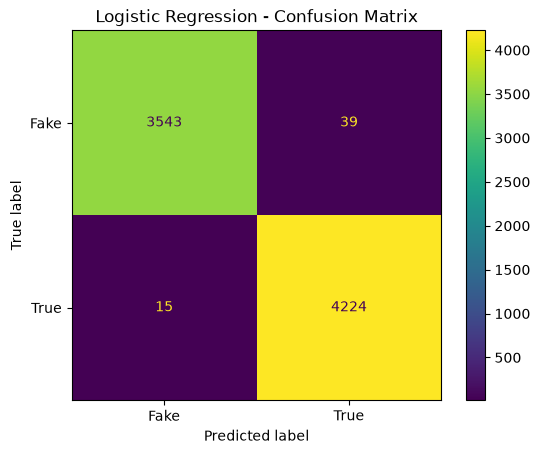

In [37]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [45]:

svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            strip_accents="unicode"
        )
    ),
    (
        "model",
        LinearSVC(
            C=1.0
        )
    )
])
print("Training Linear SVM...")

svm_pipeline.fit(
    X_train,
    y_train
)
svm_pred = svm_pipeline.predict(X_test)

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=["Fake", "True"],
        digits=4
    )
)

Training Linear SVM...
              precision    recall  f1-score   support

        Fake     0.9972    0.9955    0.9964      3582
        True     0.9962    0.9976    0.9969      4239

    accuracy                         0.9967      7821
   macro avg     0.9967    0.9966    0.9967      7821
weighted avg     0.9967    0.9967    0.9967      7821



In [46]:
nb_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "model",
        MultinomialNB()
    )
])
print("Training Naive Bayes...")

nb_pipeline.fit(
    X_train,
    y_train
)

nb_pred = nb_pipeline.predict(X_test)

Training Naive Bayes...


In [47]:
print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["Fake", "True"],
        digits=4
    )
)

              precision    recall  f1-score   support

        Fake     0.9552    0.9523    0.9537      3582
        True     0.9598    0.9623    0.9610      4239

    accuracy                         0.9577      7821
   macro avg     0.9575    0.9573    0.9574      7821
weighted avg     0.9577    0.9577    0.9577      7821



In [48]:
models = {
    "Logistic Regression": lr_pred,
    "Linear SVM": svm_pred,
    "Naive Bayes": nb_pred
}

results = []

for name, predictions in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "F1 Score",
    ascending=False
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
1           Linear SVM  0.996676   0.996676  0.996676  0.996675
0  Logistic Regression  0.993096   0.993111  0.993096  0.993094
2          Naive Bayes  0.957678   0.957672  0.957678  0.957673


In [49]:
#now do used cross validation

In [50]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_cv = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            strip_accents="unicode"
        )
    ),
    (
        "model",
        LinearSVC(C=1.0)
    )
])

cv_results = cross_validate(
    svm_cv,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted"
    ],
    n_jobs=-1
)

print("5-Fold Cross Validation")
print("------------------------")

print(
    f"Accuracy : {cv_results['test_accuracy'].mean():.4f}"
)

print(
    f"Precision: {cv_results['test_precision_weighted'].mean():.4f}"
)

print(
    f"Recall   : {cv_results['test_recall_weighted'].mean():.4f}"
)

print(
    f"F1 Score : {cv_results['test_f1_weighted'].mean():.4f}"
)

print("\nStandard Deviation")
print(
    f"Accuracy Std: {cv_results['test_accuracy'].std():.4f}"
)

print(
    f"F1 Std      : {cv_results['test_f1_weighted'].std():.4f}"
)

5-Fold Cross Validation
------------------------
Accuracy : 0.9962
Precision: 0.9962
Recall   : 0.9962
F1 Score : 0.9962

Standard Deviation
Accuracy Std: 0.0003
F1 Std      : 0.0003


In [51]:
# Final Linear SVM model
final_svm = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            strip_accents="unicode"
        )
    ),
    (
        "model",
        LinearSVC(C=1.0)
    )
])

# Train on complete training data
final_svm.fit(X_train, y_train)

# Predict on untouched test data
y_pred = final_svm.predict(X_test)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Final Test Results")
print("------------------")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "True"]
))

Final Test Results
------------------
Accuracy : 0.9967
Precision: 0.9962
Recall   : 0.9976
F1 Score : 0.9969

Classification Report
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3582
        True       1.00      1.00      1.00      4239

    accuracy                           1.00      7821
   macro avg       1.00      1.00      1.00      7821
weighted avg       1.00      1.00      1.00      7821



Confusion Matrix:
[[3566   16]
 [  10 4229]]


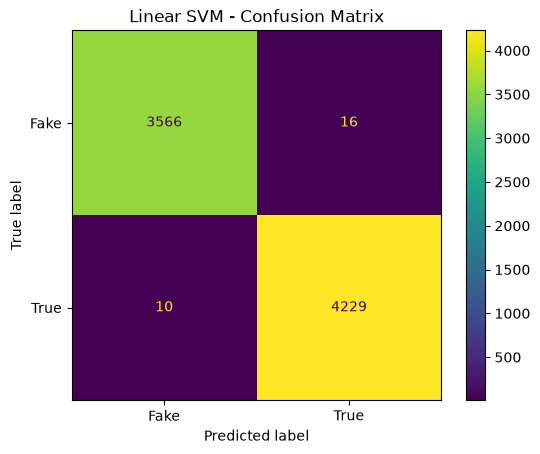

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)

disp.plot()
plt.title("Linear SVM - Confusion Matrix")
plt.show()

In [53]:
# Create a copy of the test data
error_analysis = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

# Keep only incorrectly predicted articles
errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].copy()

print("Total test articles:", len(error_analysis))
print("Misclassified articles:", len(errors))

print("\nError breakdown:")
print(pd.crosstab(
    errors["actual"],
    errors["predicted"],
    rownames=["Actual"],
    colnames=["Predicted"]
))

Total test articles: 7821
Misclassified articles: 26

Error breakdown:
Predicted   0   1
Actual           
0           0  16
1          10   0


In [54]:
# Show the first 10 misclassified articles
for i, row in errors.head(10).iterrows():

    print("=" * 100)

    print("ACTUAL:",
          "Fake" if row["actual"] == 0 else "True")

    print("PREDICTED:",
          "Fake" if row["predicted"] == 0 else "True")

    print("\nARTICLE:")
    print(row["text"][:1500])

ACTUAL: Fake
PREDICTED: True

ARTICLE:
breaking north korea detains american student for hostile act apparently it takes just one american student to destroy the unity in north korea north korea has detained a u s university student the third western citizen known to be held in the isolated state for committing a hostile act and wanting to destroy the country s unity it said on friday and was detained at pyongyang airport on jan 2 ahead of a flight back to china said gareth johnson of young pioneer tours which organized the visit according to the north s official kcna news agency warmbier entered north korea as a tourist and was caught committing a hostile act against the state which it said was tolerated and manipulated by the u s government advertisingan official at the u s embassy in the south korean capital seoul said it was aware of the reported arrest the u s state department in washington had no immediate comment johnson said china based young pioneer tours was in contact with w

In [55]:
import re

def remove_source_markers(text):
    text = str(text)

    text = re.sub(
        r'\breuters\b',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r'\baccording to reuters\b',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(
        r'\bvia reuters\b',
        ' ',
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [56]:
X_train_clean = X_train.apply(remove_source_markers)
X_test_clean = X_test.apply(remove_source_markers)

print("Original:")
print(X_train.iloc[0][:300])

print("\nAfter removing source markers:")
print(X_train_clean.iloc[0][:300])

Original:
another clinton casualty activist murdered after openly blaming hillary for meddling role in honduran coup video when far left publications like democracy now and global research start questioning hillary s involvement in the murder of honduran environmental activist berta c ceres there is probably 

After removing source markers:
another clinton casualty activist murdered after openly blaming hillary for meddling role in honduran coup video when far left publications like democracy now and global research start questioning hillary s involvement in the murder of honduran environmental activist berta c ceres there is probably 


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

clean_svm = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=30000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            strip_accents="unicode"
        )
    ),
    (
        "model",
        LinearSVC(C=1.0)
    )
])

clean_svm.fit(X_train_clean, y_train)

y_pred_clean = clean_svm.predict(X_test_clean)

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Leakage-Reduced Test Results")
print("----------------------------")

print(f"Accuracy : {accuracy_score(y_test, y_pred_clean):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_clean):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_clean):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_clean):.4f}")

print("\nClassification Report")

print(classification_report(
    y_test,
    y_pred_clean,
    target_names=["Fake", "True"]
))

Leakage-Reduced Test Results
----------------------------
Accuracy : 0.9945
Precision: 0.9932
Recall   : 0.9967
F1 Score : 0.9949

Classification Report
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3582
        True       0.99      1.00      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [59]:
import joblib

# Save the complete TF-IDF + Linear SVM pipeline
joblib.dump(final_svm, "fake_news_pipeline.pkl")

print("Model saved successfully!")

Model saved successfully!


In [60]:
# Load the saved pipeline
loaded_model = joblib.load("fake_news_pipeline.pkl")

# Test prediction
test_news = """
The government announced a new policy today to improve the country's economy.
"""

prediction = loaded_model.predict([test_news])[0]

if prediction == 0:
    print("Prediction: FAKE")
else:
    print("Prediction: TRUE")

Prediction: FAKE
